In [1]:
# Classificação Automática de Atividades Culturais e Educacionais
# 02 - Preparação do texto com TF-IDF
#
# Integrantes: Beatriz Aparecida de Mello Barbosa (10354067), Bruna Gonçalves Corte David (10425696),
#              Henrique Brainer Costa (10420717), João Pedro Queiroz de Andrade (10425822),
#              Júlia Andrade (10428513)
#
# Conteúdo: monta o texto de cada atividade, transforma o texto em números com TF-IDF, testa o
#           efeito de remover as palavras comuns do português e separa treino e teste.
#
# Alterações:
#   2026-09-25 - Bruna - notebook refeito do zero, reunindo os testes de TF-IDF e de remoção de
#                        stopwords que vínhamos fazendo soltos

In [2]:
# ====================================================================================================
#                                  CARREGAMENTO DA TABELA ÚNICA
# ====================================================================================================
import pandas as pd                                                   # leitura e manipulação das tabelas
import matplotlib.pyplot as plt                                       # gráficos que vão para o artigo

activities = pd.read_csv("../data/processed/activities.csv", sep=";", encoding="utf-8-sig")   # tabela gerada pelo notebook 01

print("Atividades carregadas:", len(activities))
activities[["source", "title", "original_categories"]].head(3)

Atividades carregadas: 693


,source,title,original_categories
0,Fábricas de Cultura,DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM L...,Biblioteca
1,Fábricas de Cultura,CONTAÇÃO DE HISTÓRIA: GPS DA ANCESTRALIDADE + ...,Biblioteca
2,Fábricas de Cultura,JARDIM SECRETO – UM DIA PLANTANDO SONHOS COM E...,Biblioteca


O texto que vai para o modelo é o título seguido da descrição. Escolhemos assim porque o título já
resume o assunto e a descrição dá o detalhe. Fora juntar os dois e tirar as atividades repetidas,
decidimos não mexer no texto, porque limpeza feita à mão para o jeito de escrever de cada site não
funcionaria numa instituição nova.

In [3]:
activities["text"] = activities["title"] + ". " + activities["description"]        # título resume, descrição detalha
activities = activities.dropna(subset=["text"])                                   # linha sem texto não serve
activities = activities.drop_duplicates(subset=["text"]).reset_index(drop=True)     # a mesma atividade aparece repetida em outra unidade

print("Atividades prontas para virar número:", len(activities))
activities["text"].head(2).tolist()

Atividades prontas para virar número: 693


['DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM LIVROS DE COLORIR – COM EQUIPE BIBLIOTECA. Venha participar da oficina Desestressar Pintando: A Arte de Relaxar com Livros de Colorir e descubra como a pintura pode contribuir para o relaxamento, o foco e o bem-estar emocional. Em celebração ao Dia do Combate ao Estresse, os participantes conhecerão os benefícios dos livros de colorir e poderão explorar a criatividade por meio de ilustrações especialmente selecionadas para acalmar a mente e despertar a imaginação.',
 'CONTAÇÃO DE HISTÓRIA: GPS DA ANCESTRALIDADE + ARTETERAPIA COM FRANCINE SANENE. Embarque em uma jornada de descobertas com GPS da Ancestralidade! Por meio de histórias da tradição oral africana, música e expressão corporal, crianças e jovens são convidados a explorar identidade, pertencimento e ancestralidade. Em seguida, transformam as emoções despertadas em criações artísticas, utilizando desenho, pintura e colagem. Uma experiência sensível, criativa e acolhedora que fortale

In [4]:
# ====================================================================================================
#                                  TEXTO VIRANDO NÚMERO (TF-IDF)
# ====================================================================================================
from sklearn.feature_extraction.text import TfidfVectorizer          # transforma texto em números pelo peso das palavras
from nltk.corpus import stopwords                                    # listas de palavras comuns, por idioma

portuguese_stopwords = stopwords.words("portuguese")                 # "de", "da", "que" e companhia

print("Stopwords do português na lista:", len(portuguese_stopwords))
portuguese_stopwords[:15]

Stopwords do português na lista: 207


['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as',
 'às',
 'até',
 'com',
 'como',
 'da']

Antes de fixar a configuração, quisemos ver o que acontece sem remover essas palavras. Rodamos o
TF-IDF do jeito padrão e olhamos quais palavras ficaram com mais peso na base inteira.

In [5]:
tfidf_keeping_stopwords = TfidfVectorizer()                                                          # configuração padrão, conta toda palavra
matrix_keeping_stopwords = tfidf_keeping_stopwords.fit_transform(activities["text"])                  # uma linha por atividade, uma coluna por palavra

average_weight_per_word = matrix_keeping_stopwords.mean(axis=0).A1                                    # peso médio da palavra em toda a base
words_keeping_stopwords = pd.Series(average_weight_per_word, index=tfidf_keeping_stopwords.get_feature_names_out())   # palavra -> peso médio

words_keeping_stopwords.sort_values(ascending=False).head(10)

de      0.115173
da      0.047285
do      0.044958
em      0.043586
para    0.038815
que     0.037637
com     0.037080
uma     0.030695
um      0.027723
na      0.027581
dtype: float64

In [6]:
tfidf_vectorizer = TfidfVectorizer(stop_words=portuguese_stopwords)                                   # a configuração que passamos a usar
tfidf_activities = tfidf_vectorizer.fit_transform(activities["text"])                                 # mesma base, sem as palavras comuns

average_weight_removing = tfidf_activities.mean(axis=0).A1                                            # peso médio de cada palavra que sobrou
words_removing_stopwords = pd.Series(average_weight_removing, index=tfidf_vectorizer.get_feature_names_out())   # palavra -> peso médio

print("Vocabulário sem remover:", len(words_keeping_stopwords), "| removendo stopwords:", len(words_removing_stopwords))
words_removing_stopwords.sort_values(ascending=False).head(10)

Vocabulário sem remover: 11313 | removendo stopwords: 11188


esporte      0.020079
prática      0.018648
anos         0.017493
sesc         0.016973
sobre        0.016596
partir       0.016317
atividade    0.016199
cultura      0.014685
crianças     0.014627
pessoas      0.014020
dtype: float64

Sem remover, as dez palavras de maior peso são todas conectivo. Removendo, aparecem palavras que
dizem do que a atividade trata. Para medir o efeito disso na prática, comparamos o quanto as
atividades parecem próximas umas das outras nos dois casos.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity                                   # mede o quanto dois textos se parecem, de 0 a 1
import numpy as np                                                                       # contas com matrizes

similarity_keeping_stopwords = cosine_similarity(matrix_keeping_stopwords)                # semelhança de cada atividade com cada outra
similarity_removing_stopwords = cosine_similarity(tfidf_activities)                       # a mesma conta, sem as palavras comuns

off_diagonal = ~np.eye(len(activities), dtype=bool)                                       # ignora a semelhança da atividade com ela mesma

print("Semelhança média sem remover stopwords:", round(similarity_keeping_stopwords[off_diagonal].mean(), 4))
print("Semelhança média removendo stopwords:", round(similarity_removing_stopwords[off_diagonal].mean(), 4))

Semelhança média sem remover stopwords: 0.0515
Semelhança média removendo stopwords: 0.0196


A semelhança média cai para menos da metade. Ou seja, boa parte do que parecia assunto em comum
entre duas atividades era só conectivo repetido. Ficamos com a configuração que remove.

In [8]:
words_per_activity = tfidf_activities.getnnz(axis=1)                                      # quantas palavras diferentes cada atividade contribui

print("Palavras no vocabulário:", tfidf_activities.shape[1])
print("Média de palavras diferentes por atividade:", round(words_per_activity.mean(), 1))
print("Atividade mais curta:", words_per_activity.min(), "| mais longa:", words_per_activity.max())

Palavras no vocabulário: 11188
Média de palavras diferentes por atividade: 66.1
Atividade mais curta: 3 | mais longa: 283


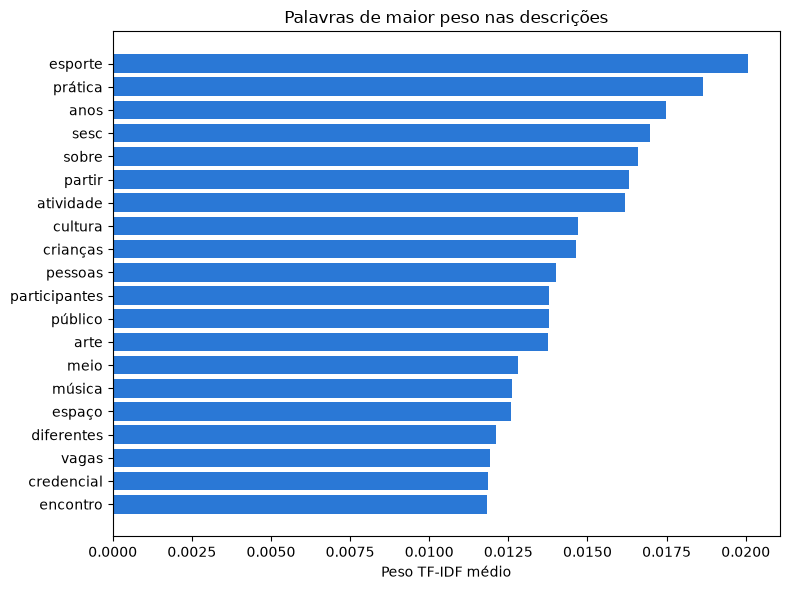

In [9]:
# ----------------------------------------------------------------------------------------------------
#                         GRÁFICO: AS 20 PALAVRAS DE MAIOR PESO NA BASE
# ----------------------------------------------------------------------------------------------------
twenty_heaviest_words = words_removing_stopwords.sort_values(ascending=False).head(20)               # o vocabulário que caracteriza a base

plt.figure(figsize=(8, 6))                                                                           # tamanho do gráfico em polegadas
plt.barh(twenty_heaviest_words.index, twenty_heaviest_words.values, color="#2a78d6")                  # barras deitadas, uma por palavra
plt.gca().invert_yaxis()                                                                             # palavra de maior peso aparece em cima
plt.xlabel("Peso TF-IDF médio")                                                                      # rótulo do eixo horizontal
plt.title("Palavras de maior peso nas descrições")                                                   # título que vai junto no artigo
plt.tight_layout()                                                                                   # evita cortar os nomes das palavras
plt.savefig("../paper/latex/figures/top_weighted_words.png", dpi=150)                                # figura usada no artigo
plt.show()

In [10]:
# ====================================================================================================
#                                 SEPARAÇÃO EM TREINO E TESTE
# ====================================================================================================
from sklearn.model_selection import train_test_split                  # separa os dados em treino e teste

train_indices, test_indices = train_test_split(activities.index, test_size=0.2, random_state=42)   # 20% guardado para teste, semente fixa

activities["split"] = "train"                                         # a maioria das atividades treina o modelo
activities.loc[test_indices, "split"] = "test"                        # o resto fica guardado para avaliar

print("Treino:", len(train_indices), "| Teste:", len(test_indices))
activities["split"].value_counts()

Treino: 554 | Teste: 139


split
train    554
test     139
Name: count, dtype: int64

Gravamos a divisão numa coluna em vez de refazer o sorteio em cada notebook. Assim o classificador
é avaliado nas mesmas atividades que ficaram de fora desde o começo, e não em alguma que já tenha
participado de outra etapa.

In [11]:
activities.to_csv("../data/processed/activities_prepared.csv", sep=";", index=False, encoding="utf-8-sig")   # tabela com texto e divisão treino/teste

print("Tabela salva em data/processed/activities_prepared.csv")
activities[["source", "title", "split"]].head(3)

Tabela salva em data/processed/activities_prepared.csv


,source,title,split
0,Fábricas de Cultura,DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM L...,train
1,Fábricas de Cultura,CONTAÇÃO DE HISTÓRIA: GPS DA ANCESTRALIDADE + ...,train
2,Fábricas de Cultura,JARDIM SECRETO – UM DIA PLANTANDO SONHOS COM E...,test
